# Who Faces the Greatest Risk in U.S. Traffic Crashes?

A person-level analysis of road-user vulnerability using NHTSA CRSS data, 2016-2020.

## tl;dr

Pedestrians and motorcyclists face the highest serious/fatal injury rates among people involved in crashes, followed by bicyclists. Enclosed-vehicle occupants have a much lower injury rate. The analysis below establishes that disparity, checks whether it persists across all five years, and tests how late-night crashes change the pattern.

## Context & Methods

The person files contain one row per person involved in a sampled crash. Each yearly person file is joined to its matching accident file by `CASENUM` and to its matching vehicle file by `CASENUM + VEH_NO`. The vehicle join separates motorcyclists from enclosed-vehicle occupants while preserving pedestrians and bicyclists that have no vehicle record. Estimates and rates use the person-level CRSS `WEIGHT`.

### Key Assumptions

- Serious or fatal injury is `INJSEV_IM` equal to 3 or 4.
- Motorcycle body-type codes are `BDYTYP_IM` values 80 through 89.
- Enclosed-vehicle occupants include drivers, passengers, and other/unknown occupants of non-motorcycle motor vehicles.
- Late night is midnight through 5:59am.
- The results describe people involved in police-reported crashes, not risk per trip or mile traveled.
- Associations with nighttime, speed, rollover, alcohol, rural roads, or age are not causal effects.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import PercentFormatter

data_dir = Path("../data")

## Data

### Join person records to crash and vehicle conditions

In [2]:
person_columns = [
    "CASENUM", "VEH_NO", "PER_NO", "PER_TYP",
    "AGE_IM", "SEX_IM", "INJSEV_IM", "WEIGHT",
]
crash_columns = [
    "CASENUM", "HOUR_IM", "LGTCON_IM", "ALCHL_IM", "URBANICITY",
]
vehicle_columns = [
    "CASENUM", "VEH_NO", "BDYTYP_IM", "SPEEDREL", "ROLLOVER", "V_ALCH_IM",
]

yearly_people = []

for short_year in range(16, 21):
    people_year = pd.read_csv(
        data_dir / f"pers_{short_year}.csv",
        usecols=person_columns,
        encoding="latin1",
        low_memory=False,
    )
    crashes_year = pd.read_csv(
        data_dir / f"acc_{short_year}.csv",
        usecols=crash_columns,
        encoding="latin1",
        low_memory=False,
    )
    vehicles_year = pd.read_csv(
        data_dir / f"veh_{short_year}.csv",
        usecols=vehicle_columns,
        encoding="latin1",
        low_memory=False,
    )

    people_year = people_year.merge(
        crashes_year,
        on="CASENUM",
        how="left",
        validate="many_to_one",
    )
    people_year = people_year.merge(
        vehicles_year,
        on=["CASENUM", "VEH_NO"],
        how="left",
        validate="many_to_one",
    )
    people_year["YEAR"] = 2000 + short_year
    yearly_people.append(people_year)

people = pd.concat(yearly_people, ignore_index=True)
people.shape

(644274, 17)

### Validate the joined grain

In [3]:
person_key = ["YEAR", "CASENUM", "VEH_NO", "PER_NO"]
in_transport_person = people["PER_TYP"].isin([1, 2, 9])
out_of_transport_occupant = people["PER_TYP"] == 3
non_motorist = ~people["PER_TYP"].isin([1, 2, 3, 9])

join_checks = pd.Series({
    "person_rows": len(people),
    "duplicate_person_keys": people.duplicated(person_key).sum(),
    "missing_crash_matches": people["HOUR_IM"].isna().sum(),
    "in_transport_people_missing_vehicle_match": people.loc[
        in_transport_person, "BDYTYP_IM"
    ].isna().sum(),
    "out_of_transport_occupants_without_vehicle_match": people.loc[
        out_of_transport_occupant, "BDYTYP_IM"
    ].isna().sum(),
    "non_motorists_without_vehicle_match": people.loc[
        non_motorist, "BDYTYP_IM"
    ].isna().sum(),
    "years": people["YEAR"].nunique(),
})
join_checks

person_rows                                         644274
duplicate_person_keys                                    0
missing_crash_matches                                    0
in_transport_people_missing_vehicle_match                0
out_of_transport_occupants_without_vehicle_match      2195
non_motorists_without_vehicle_match                  23052
years                                                    5
dtype: int64

### Engineer road-user and crash-condition features

In [4]:
def classify_road_user(row):
    if row["PER_TYP"] == 5:
        return "Pedestrian"
    if row["PER_TYP"] in [6, 7]:
        return "Bicyclist"
    if row["PER_TYP"] in [1, 2, 3, 9] and 80 <= row["BDYTYP_IM"] <= 89:
        return "Motorcyclist"
    if row["PER_TYP"] in [1, 2, 3, 9]:
        return "Enclosed-vehicle occupant"
    if row["PER_TYP"] == 8:
        return "Personal conveyance"
    return "Other road user"


people["road_user_group"] = people.apply(classify_road_user, axis=1)
people["serious_or_fatal"] = people["INJSEV_IM"].isin([3, 4])
people["fatal_injury"] = people["INJSEV_IM"] == 4
people["dark"] = people["LGTCON_IM"].isin([2, 3, 6])
people["late_night"] = people["HOUR_IM"].between(0, 5)
people["crash_alcohol_involved"] = people["ALCHL_IM"] == 1
people["speed_related_vehicle"] = people["SPEEDREL"].isin([2, 3, 4, 5])
people["rollover_vehicle"] = people["ROLLOVER"].isin([1, 2, 9])
people["rural"] = people["URBANICITY"] == 2
people["age_group"] = pd.cut(
    people["AGE_IM"],
    bins=[-1, 15, 24, 44, 64, 120],
    labels=["0-15", "16-24", "25-44", "45-64", "65+"],
)

people["road_user_group"].value_counts()

road_user_group
Enclosed-vehicle occupant    604670
Motorcyclist                  16552
Pedestrian                    13413
Bicyclist                      8683
Personal conveyance             607
Other road user                 349
Name: count, dtype: int64

## Results

### Baseline vulnerability by road-user type

In [5]:
def weighted_person_summary(df, group_columns):
    if isinstance(group_columns, str):
        group_columns = [group_columns]

    analysis = df.dropna(subset=group_columns + ["WEIGHT"]).copy()
    analysis["weighted_serious"] = analysis["WEIGHT"] * analysis["serious_or_fatal"]
    analysis["weighted_fatal"] = analysis["WEIGHT"] * analysis["fatal_injury"]

    summary = analysis.groupby(group_columns, observed=True).agg(
        sample_size=("WEIGHT", "size"),
        estimated_people=("WEIGHT", "sum"),
        estimated_serious_or_fatal=("weighted_serious", "sum"),
        estimated_fatal=("weighted_fatal", "sum"),
    )
    summary["serious_or_fatal_rate"] = (
        summary["estimated_serious_or_fatal"] / summary["estimated_people"]
    )
    summary["fatal_rate"] = summary["estimated_fatal"] / summary["estimated_people"]
    return summary.reset_index()


main_groups = [
    "Enclosed-vehicle occupant",
    "Bicyclist",
    "Motorcyclist",
    "Pedestrian",
]
road_user_summary = weighted_person_summary(
    people[people["road_user_group"].isin(main_groups)],
    "road_user_group",
).set_index("road_user_group").loc[main_groups].reset_index()

road_user_summary.style.format({
    "estimated_people": "{:,.0f}",
    "estimated_serious_or_fatal": "{:,.0f}",
    "estimated_fatal": "{:,.0f}",
    "serious_or_fatal_rate": "{:.1%}",
    "fatal_rate": "{:.1%}",
})

,road_user_group,sample_size,estimated_people,estimated_serious_or_fatal,estimated_fatal,serious_or_fatal_rate,fatal_rate
0,Enclosed-vehicle occupant,604670,"75,699,717","913,850","129,375",1.2%,0.2%
1,Bicyclist,8683,"273,697","32,829","4,085",12.0%,1.5%
2,Motorcyclist,16552,"614,354","139,271","22,638",22.7%,3.7%
3,Pedestrian,13413,"400,831","99,075","27,803",24.7%,6.9%


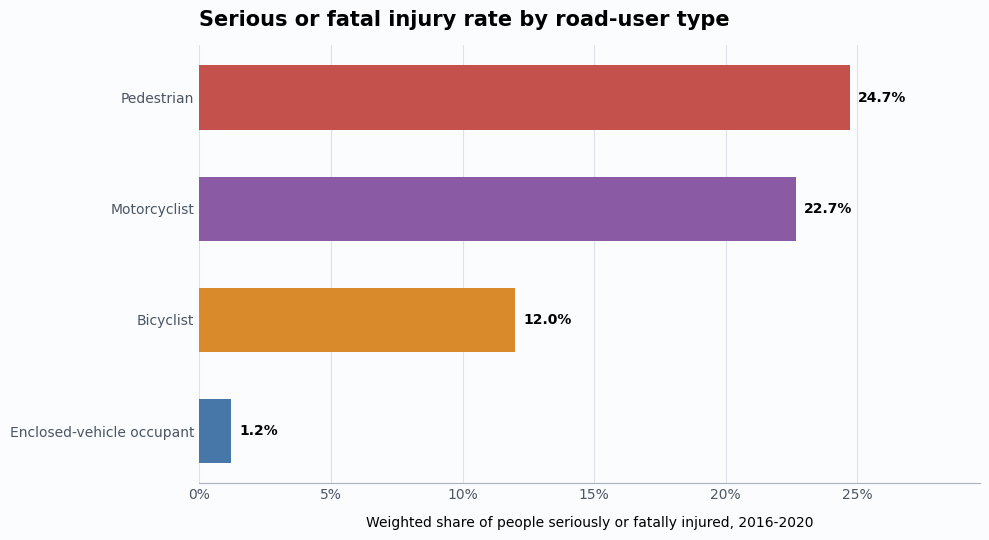

In [6]:
palette = {
    "Enclosed-vehicle occupant": "#4776A8",
    "Bicyclist": "#D98B2B",
    "Motorcyclist": "#8A5AA5",
    "Pedestrian": "#C4514C",
}

plot_data = road_user_summary.sort_values("serious_or_fatal_rate")
fig, ax = plt.subplots(figsize=(10, 5.5), facecolor="#FBFCFE")
ax.set_facecolor("#FBFCFE")
bars = ax.barh(
    plot_data["road_user_group"],
    plot_data["serious_or_fatal_rate"],
    color=[palette[group] for group in plot_data["road_user_group"]],
    height=0.58,
)
ax.bar_label(
    bars,
    labels=[f"{value:.1%}" for value in plot_data["serious_or_fatal_rate"]],
    padding=6,
    fontweight="semibold",
)
ax.set_title(
    "Serious or fatal injury rate by road-user type",
    loc="left",
    fontsize=15,
    fontweight="bold",
    pad=14,
)
ax.set_xlabel(
    "Weighted share of people seriously or fatally injured, 2016-2020",
    labelpad=10,
)
ax.set_ylabel("")
ax.set_xlim(0, plot_data["serious_or_fatal_rate"].max() * 1.2)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.grid(axis="x", color="#DDE2E8", linewidth=0.8)
ax.set_axisbelow(True)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#AAB2BD")
ax.tick_params(colors="#4B5563", length=0)
fig.tight_layout()
plt.show()

### Check whether the disparity persists by year

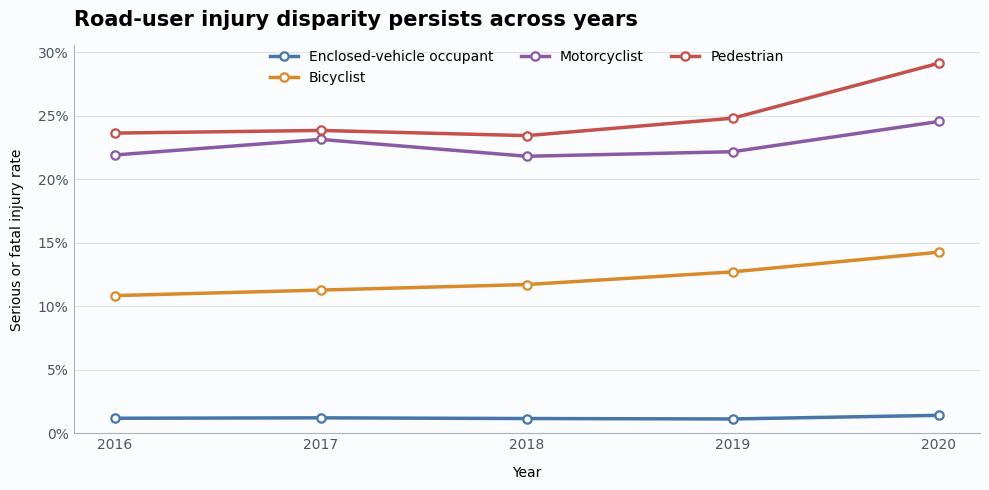

In [7]:
yearly_summary = weighted_person_summary(
    people[people["road_user_group"].isin(main_groups)],
    ["YEAR", "road_user_group"],
)

fig, ax = plt.subplots(figsize=(10, 5), facecolor="#FBFCFE")
ax.set_facecolor("#FBFCFE")
for group in main_groups:
    group_data = yearly_summary[yearly_summary["road_user_group"] == group]
    ax.plot(
        group_data["YEAR"],
        group_data["serious_or_fatal_rate"],
        label=group,
        color=palette[group],
        marker="o",
        markerfacecolor="#FBFCFE",
        markeredgewidth=1.6,
        linewidth=2.5,
    )

ax.set_title("Road-user injury disparity persists across years", loc="left", fontsize=15, fontweight="bold", pad=14)
ax.set_xlabel("Year", labelpad=10)
ax.set_ylabel("Serious or fatal injury rate", labelpad=10)
ax.set_xticks(range(2016, 2021))
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.grid(axis="y", color="#DDE2E8", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#AAB2BD")
ax.tick_params(colors="#4B5563", length=0)
ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.02))
fig.tight_layout()
plt.show()

### How does late night change vulnerability?

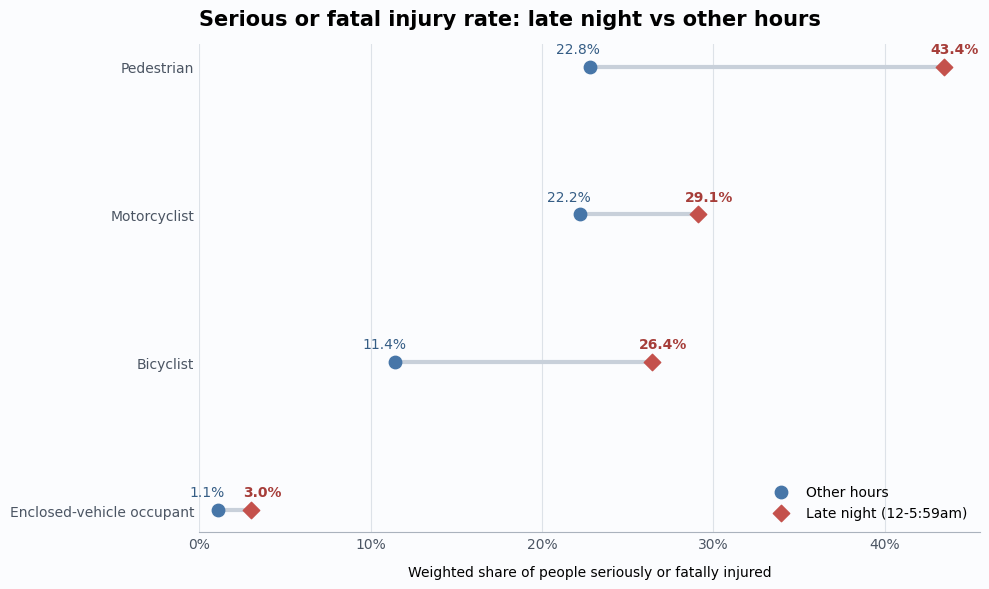

,road_user_group,late_night,sample_size,estimated_people,estimated_serious_or_fatal,estimated_fatal,serious_or_fatal_rate,fatal_rate
0,Bicyclist,False,8365,"263,552","30,146","3,451",11.4%,1.3%
1,Bicyclist,True,318,"10,145","2,683",634,26.4%,6.3%
2,Enclosed-vehicle occupant,False,568704,"71,457,381","784,753","101,304",1.1%,0.1%
3,Enclosed-vehicle occupant,True,35966,"4,242,336","129,098","28,072",3.0%,0.7%
4,Motorcyclist,False,15413,"572,535","127,111","19,742",22.2%,3.4%
5,Motorcyclist,True,1139,"41,819","12,161","2,896",29.1%,6.9%
6,Pedestrian,False,12161,"363,157","82,706","21,092",22.8%,5.8%
7,Pedestrian,True,1252,"37,674","16,369","6,710",43.4%,17.8%


In [8]:
night_summary = weighted_person_summary(
    people[people["road_user_group"].isin(main_groups)],
    ["road_user_group", "late_night"],
)
night_rates = night_summary.pivot(
    index="road_user_group",
    columns="late_night",
    values="serious_or_fatal_rate",
).loc[main_groups]

fig, ax = plt.subplots(figsize=(10, 6), facecolor="#FBFCFE")
ax.set_facecolor("#FBFCFE")

for position, group in enumerate(main_groups):
    other_hours = night_rates.loc[group, False]
    late_night = night_rates.loc[group, True]
    ax.plot(
        [other_hours, late_night],
        [position, position],
        color="#C8D0DA",
        linewidth=3,
        zorder=1,
    )
    ax.scatter(
        other_hours,
        position,
        color="#4776A8",
        marker="o",
        s=80,
        label="Other hours" if position == 0 else None,
        zorder=2,
    )
    ax.scatter(
        late_night,
        position,
        color="#C4514C",
        marker="D",
        s=70,
        label="Late night (12-5:59am)" if position == 0 else None,
        zorder=2,
    )
    ax.annotate(f"{other_hours:.1%}", (other_hours, position), xytext=(-8, 10), textcoords="offset points", ha="center", color="#355D85")
    ax.annotate(f"{late_night:.1%}", (late_night, position), xytext=(8, 10), textcoords="offset points", ha="center", color="#A63D39", fontweight="semibold")

ax.set_title(
    "Serious or fatal injury rate: late night vs other hours",
    loc="left",
    fontsize=15,
    fontweight="bold",
    pad=14,
)
ax.set_xlabel("Weighted share of people seriously or fatally injured", labelpad=10)
ax.set_yticks(range(len(main_groups)), main_groups)
ax.set_xlim(left=0)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.grid(axis="x", color="#DDE2E8", linewidth=0.8)
ax.set_axisbelow(True)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#AAB2BD")
ax.tick_params(colors="#4B5563", length=0)
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
plt.show()

night_summary.style.format({
    "estimated_people": "{:,.0f}",
    "estimated_serious_or_fatal": "{:,.0f}",
    "estimated_fatal": "{:,.0f}",
    "serious_or_fatal_rate": "{:.1%}",
    "fatal_rate": "{:.1%}",
})

## Takeaways

- Pedestrians and motorcyclists face the highest serious/fatal injury rates among people involved in crashes.
- Bicyclists also face substantially higher injury severity than enclosed-vehicle occupants.
- The disparity appears in every year from 2016 through 2020 rather than being driven by one unusual year.
- Late-night crashes increase severe-injury rates, but the size of that increase differs by road-user group.
- Vehicle fields now make it possible to study speed, rollover, and vehicle-level alcohol involvement among motorcyclists and enclosed-vehicle occupants.

These are conditional injury rates among people already involved in police-reported crashes. They do not measure population risk, trip risk, or risk per mile traveled.